In [1]:
import copy
import sys
import os
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
# The code is desigend to be run on both CPU and GPU. 
# If cupy is available, it will use GPU for computation, 
# otherwise it will fall back to numpy on CPU.
try:
    import cupy as cp
    a=cp.array([0])
except:
    import numpy as cp

# These directories are used to store the custom modules, data and results. You can change them to your own directories.
code_dir = '/n/data2/hms/neurobio/harvey/siyan/arctic/'
data_dir = f'/n/data2/hms/neurobio/harvey/siyan/data/mesoscope/'
root_dir = f'/n/data2/hms/neurobio/harvey/siyan/arctic/example_results/fit_to_trial_average/'

# Load custom modules
os.sys.path.insert(0,code_dir)
from src.Model import RnnModel as rnn
from src.Optimizer import Rls, RlsZeroOutDiagonal
from scripts.Ymaze_simulation.LoadData import load_charlotte_delay
from scripts.Ymaze_simulation.Environment import YMaze
from scripts.Ymaze_simulation.TrainEval_closed_loop import train_closed_loop,evaluation_closed_loop
from scripts.Ymaze_analyses.Utils import binning_maze

In [3]:
"""
Load data (neural and behavioral) and set up training and testing trials for cross validation. 
"""
filename = 'CA63/190703/'
result_dir = root_dir + filename
if not os.path.exists(result_dir):
    os.makedirs(result_dir)

delay, binary_labels, frame_trial, activity, behavior=load_charlotte_delay(data_dir, filename)
n_neuron = activity.shape[0]
n_frame = activity.shape[1]
n_trial = binary_labels.shape[1]
cor_trial_idxes=np.where(binary_labels[2]==1)[0]
n_cor_trials=cor_trial_idxes.shape[0]
#transfer data to cuda
cues=cp.array(binary_labels[0])
activity = cp.array(activity)
activity[activity>=1]=1-1e-4
behavior = cp.array(behavior)
behavior[cp.isnan(behavior)] = 0
frame_trial = cp.array(frame_trial)

# For fitting trial average, the individual trials are first binned by instantaneous forward position, 
# then the trial average is computed for each cue condition (correct choice only). 
lens=cp.array([cp.sum(frame_trial==i) for i in cor_trial_idxes])
vmin = 5
vmax = 235
bins = int(cp.mean(lens).item())
activity_binned=cp.array(binning_maze(activity,vmin,vmax,bins,
                                   cor_trial_idxes,behavior[3,:],frame_trial))
behavior_binned=cp.array(binning_maze(behavior,vmin,vmax,bins,
                                   cor_trial_idxes,behavior[3,:],frame_trial))
activity_ave=cp.hstack((cp.mean(activity_binned[cues[cor_trial_idxes]==0],axis=0),#right trial-ave
                        cp.mean(activity_binned[cues[cor_trial_idxes]==1],axis=0)))#left trial-ave
behavior_ave=cp.hstack((cp.mean(behavior_binned[cues[cor_trial_idxes]==0],axis=0),
                        cp.mean(behavior_binned[cues[cor_trial_idxes]==1],axis=0)))
# for easy indexing, the trial average is treated as two additional trials with new trial ids.
activity=cp.hstack((activity,activity_ave))
behavior=cp.hstack((behavior,behavior_ave))
cues=cp.hstack((cues,cp.array([0,1])))
max_id=cp.nanmax(frame_trial).item()
frame_trial=cp.hstack([frame_trial,cp.array([max_id+1]*bins),cp.array([max_id+2]*bins)])
train_trial_idxes=np.array([int(max_id+1),int(max_id+2)])
test_trial_idxes=cor_trial_idxes
eval_trial_idxes=np.hstack((test_trial_idxes,train_trial_idxes))

# Fit to trial average with low learning rate results in continuous attractor dynamics

Note there are basically only 2 training trials (the two averages). The trained model is then evaluated on the initial condition of all individual trials to probe the dynamics. 

In [3]:
lr_out= 1 #learning rate of output weights
lr_in= 5 #learning rate of input and recurrent weights
noise= 0.1 #noise level added to the RNN activity during training, which can help with generalization.
n_epoch = 500 #number of training epochs, each epoch contains one pass through all training trials.

#initialize objects
net=rnn(dtData=0.186, dt=0.0093, tau=0.1, g=0, N=n_neuron,
        phi='modifiedtanh',input_dim=11,output_dim=3,observation_dim=5)
env=YMaze(delay)
optim_outputs=Rls(M=n_neuron,lr=lr_out)
optim_inputs=RlsZeroOutDiagonal(M=n_neuron+11,N=n_neuron,reg_ratio=500,lr=lr_in)

#train loop
t0=time.perf_counter()
J_neu,J_beh = train_closed_loop(net,env,
                                optim_inputs,optim_outputs,
                                cues,activity,behavior,frame_trial,
                                train_trial_idxes,
                                cur_noise=noise,n_epoch=n_epoch)
elapsed = time.perf_counter() - t0
print(f"Last run: 100% ({n_epoch}/{n_epoch}) in {elapsed:.2f} s")

cp.save(result_dir + f'Jneu_{n_epoch}.npy', J_neu)
cp.save(result_dir + f'Jbeh_{n_epoch}.npy', J_beh)

100%|██████████| 500/500 [1:06:08<00:00,  7.94s/it]

Last run: 100% (500/500) in 3968.55 s


In [ ]:
# This cell takes about 15 minutes to run on GPU
R_eval, beh_eval, frame_trial_eval = evaluation_closed_loop(net,env,
                                                            cues, activity, behavior,frame_trial,
                                                            eval_trial_idxes,
                                                            cur_noise=0)
cp.save(result_dir + f'R_lr={lr_in}.npy', R_eval)
cp.save(result_dir + f'beh_output_lr={lr_in}.npy', beh_eval)
np.save(result_dir + f'frame_trial_eval_lr={lr_in}.npy', np.array(frame_trial_eval))

### Neural activity projection on CD

In [18]:
lr_in=5
from scripts.Ymaze_analyses.Utils import model_correctness
beh_model=np.load(result_dir + f'beh_output_lr={lr_in}.npy')
frame_trial_eval=np.load(result_dir + f'frame_trial_eval_lr={lr_in}.npy')
choices=binary_labels[1,cor_trial_idxes]
correct_m=model_correctness(beh_model,frame_trial_eval,cor_trial_idxes,choices)

In [20]:
#Data projection
R_binned_data=binning_maze(activity,5,235,46,
                           cor_trial_idxes,behavior[3],frame_trial)
cd=np.mean(R_binned_data[choices==1,:,:],axis=0)-\
   np.mean(R_binned_data[choices==0,:,:],axis=0)
cd=cd/np.linalg.norm(cd,axis=0)[np.newaxis,:]
cd_mid=(np.mean(R_binned_data[choices==1,:,:],axis=0)+np.mean(R_binned_data[choices==0,:,:],axis=0))/2
cd_proj_data=np.einsum('int,nt->it',R_binned_data-cd_mid[np.newaxis,:,:],cd)

#Model projection
R_model=np.load(result_dir + f'R_lr={lr_in}.npy')
R_binned_model=binning_maze(R_model,5,235,46,
                            eval_trial_idxes,beh_model[3],frame_trial_eval)
cd=R_binned_model[-2]-R_binned_model[-1]
cd=cd/np.linalg.norm(cd,axis=0)[np.newaxis,:]
cd_mid=(R_binned_model[-2]+R_binned_model[-1])/2
cd_proj_model=np.einsum('int,nt->it',R_binned_model-cd_mid[np.newaxis,:,:],cd)

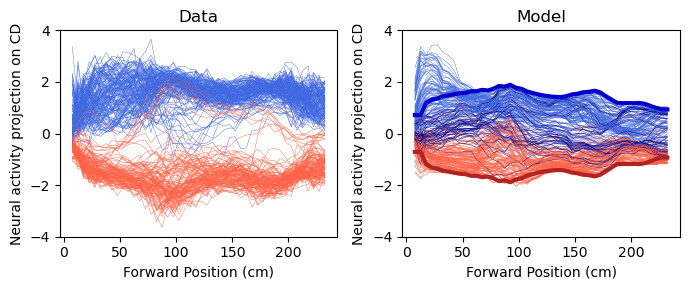

In [32]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
colors=[['darkblue','royalblue'],['darkred','tomato']]
#plot individual trials
for idx, trial_index in enumerate(cor_trial_idxes):
    ax[0].plot(np.linspace(7.5,232.5,46), 
             -1*cd_proj_data[idx],
             c=colors[binary_labels[1][trial_index]][1],lw=0.3)
    ax[1].plot(np.linspace(7.5,232.5,46), 
             -1*cd_proj_model[idx],
             c=colors[binary_labels[1][trial_index]][int(correct_m[idx])],lw=0.3)
#plot the simulation from trial averaged initial conditions
ax[1].plot(np.linspace(7.5,232.5,46), 
        -1*cd_proj_model[-2],
        c='firebrick',lw=3)
ax[1].plot(np.linspace(7.5,232.5,46), 
        -1*cd_proj_model[-1],
        c='mediumblue',lw=3)
ax[0].set_title('Data')
ax[0].set_xlabel('Forward Position (cm)')
ax[0].set_ylabel('Neural activity projection on CD')
ax[0].set_ylim(-4,4)
ax[1].set_title('Model')
ax[1].set_xlabel('Forward Position (cm)')
ax[1].set_ylabel('Neural activity projection on CD')
ax[1].set_ylim(-4,4)
plt.tight_layout()

### Lateral velocity

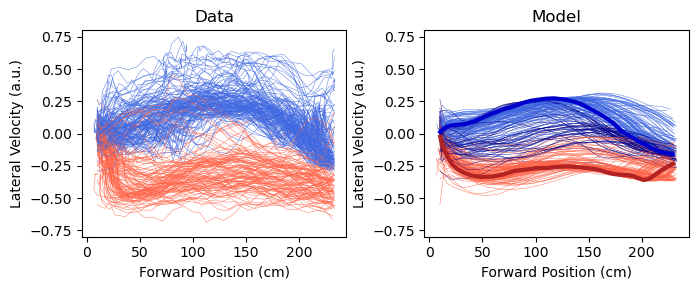

In [33]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
colors=[['darkblue','royalblue'],['darkred','tomato']]
#plot individual trials
for idx, trial_index in enumerate(cor_trial_idxes):
    ax[0].plot(cp.asnumpy(behavior[3, frame_trial == trial_index]), 
             -1*cp.asnumpy(behavior[1, frame_trial == trial_index]),
             c=colors[binary_labels[1][trial_index]][1],lw=0.3)
    ax[1].plot(cp.asnumpy(beh_model[3, np.array(frame_trial_eval) == trial_index]), 
             -1*cp.asnumpy(beh_model[1, np.array(frame_trial_eval) == trial_index]),
             c=colors[binary_labels[1][trial_index]][int(correct_m[idx])],lw=0.3)
#plot the simulation from trial averaged initial conditions
ax[1].plot(cp.asnumpy(beh_model[3, np.array(frame_trial_eval) == train_trial_idxes[0]]), 
        -1*cp.asnumpy(beh_model[1, np.array(frame_trial_eval) == train_trial_idxes[0]]),
        c='firebrick',lw=3)
ax[1].plot(cp.asnumpy(beh_model[3, np.array(frame_trial_eval) == train_trial_idxes[1]]), 
        -1*cp.asnumpy(beh_model[1, np.array(frame_trial_eval) == train_trial_idxes[1]]),
        c='mediumblue',lw=3)
ax[0].set_title('Data')
ax[0].set_xlabel('Forward Position (cm)')
ax[0].set_ylabel('Lateral Velocity (a.u.)')
ax[0].set_ylim(-0.8,0.8)
ax[1].set_title('Model')
ax[1].set_xlabel('Forward Position (cm)')
ax[1].set_ylabel('Lateral Velocity (a.u.)')
ax[1].set_ylim(-0.8,0.8)
plt.tight_layout()

# Fit to trial average with high learning rate results in point attractor dynamics

In [ ]:
lr_out= 1 #learning rate of output weights
lr_in= 40 #learning rate of input and recurrent weights
noise= 0.1 #noise level added to the RNN activity during training, which can help with generalization.
n_epoch = 500 #number of training epochs, each epoch contains one pass through all training trials.

#initialize objects
net=rnn(dtData=0.186, dt=0.0093, tau=0.1, g=0, N=n_neuron,
        phi='modifiedtanh',input_dim=11,output_dim=3,observation_dim=5)
env=YMaze(delay)
optim_outputs=Rls(M=n_neuron,lr=lr_out)
optim_inputs=RlsZeroOutDiagonal(M=n_neuron+11,N=n_neuron,reg_ratio=500,lr=lr_in)

#train loop
t0=time.perf_counter()
J_neu,J_beh = train_closed_loop(net,env,
                                optim_inputs,optim_outputs,
                                cues,activity,behavior,frame_trial,
                                train_trial_idxes,
                                cur_noise=noise,n_epoch=n_epoch)
elapsed = time.perf_counter() - t0
print(f"Last run: 100% ({n_epoch}/{n_epoch}) in {elapsed:.2f} s")

cp.save(result_dir + f'Jneu_{n_epoch}_lr={lr_in}.npy', J_neu)
cp.save(result_dir + f'Jbeh_{n_epoch}_lr={lr_in}.npy', J_beh)

100%|██████████| 500/500 [1:07:01<00:00,  8.04s/it]

Last run: 100% (500/500) in 4021.86 s


In [7]:
R_eval, beh_eval, frame_trial_eval = evaluation_closed_loop(net,env,
                                                            cues, activity, behavior,frame_trial,
                                                            eval_trial_idxes,
                                                            cur_noise=0)
cp.save(result_dir + f'R_lr={lr_in}.npy', R_eval)
cp.save(result_dir + f'beh_output_lr={lr_in}.npy', beh_eval)
np.save(result_dir + f'frame_trial_eval_lr={lr_in}.npy', np.array(frame_trial_eval))

Neural activity projection on CD

In [34]:
from scripts.Ymaze_analyses.Utils import model_correctness
lr_in=40
beh_model=np.load(result_dir + f'beh_output_lr={lr_in}.npy')
frame_trial_eval=np.load(result_dir + f'frame_trial_eval_lr={lr_in}.npy')
choices=binary_labels[1,cor_trial_idxes]
correct_m=model_correctness(beh_model,frame_trial_eval,cor_trial_idxes,choices)

In [35]:
#Data projection
R_binned_data=binning_maze(activity,5,235,46,
                           cor_trial_idxes,behavior[3],frame_trial)
cd=np.mean(R_binned_data[choices==1,:,:],axis=0)-\
   np.mean(R_binned_data[choices==0,:,:],axis=0)
cd=cd/np.linalg.norm(cd,axis=0)[np.newaxis,:]
cd_mid=(np.mean(R_binned_data[choices==1,:,:],axis=0)+np.mean(R_binned_data[choices==0,:,:],axis=0))/2
cd_proj_data=np.einsum('int,nt->it',R_binned_data-cd_mid[np.newaxis,:,:],cd)

#Model projection
R_model=np.load(result_dir + f'R_lr={lr_in}.npy')
R_binned_model=binning_maze(R_model,5,235,46,
                            eval_trial_idxes,beh_model[3],frame_trial_eval)
cd=R_binned_model[-2]-R_binned_model[-1]
cd=cd/np.linalg.norm(cd,axis=0)[np.newaxis,:]
cd_mid=(R_binned_model[-2]+R_binned_model[-1])/2
cd_proj_model=np.einsum('int,nt->it',R_binned_model-cd_mid[np.newaxis,:,:],cd)

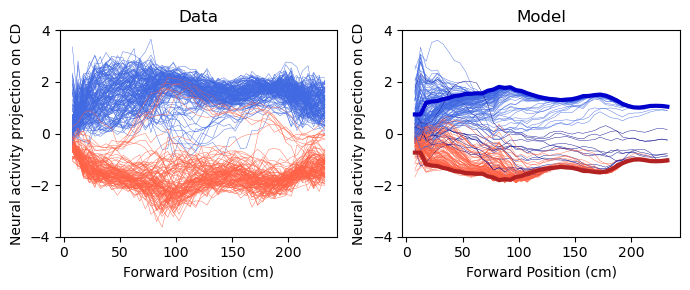

In [36]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
colors=[['darkblue','royalblue'],['darkred','tomato']]
#plot individual trials
for idx, trial_index in enumerate(cor_trial_idxes):
    ax[0].plot(np.linspace(7.5,232.5,46), 
             -1*cd_proj_data[idx],
             c=colors[binary_labels[1][trial_index]][1],lw=0.3)
    ax[1].plot(np.linspace(7.5,232.5,46), 
             -1*cd_proj_model[idx],
             c=colors[binary_labels[1][trial_index]][int(correct_m[idx])],lw=0.3)
#plot the simulation from trial averaged initial conditions
ax[1].plot(np.linspace(7.5,232.5,46), 
        -1*cd_proj_model[-2],
        c='firebrick',lw=3)
ax[1].plot(np.linspace(7.5,232.5,46), 
        -1*cd_proj_model[-1],
        c='mediumblue',lw=3)
ax[0].set_title('Data')
ax[0].set_xlabel('Forward Position (cm)')
ax[0].set_ylabel('Neural activity projection on CD')
ax[0].set_ylim(-4,4)
ax[1].set_title('Model')
ax[1].set_xlabel('Forward Position (cm)')
ax[1].set_ylabel('Neural activity projection on CD')
ax[1].set_ylim(-4,4)
plt.tight_layout()

Lateral velocity

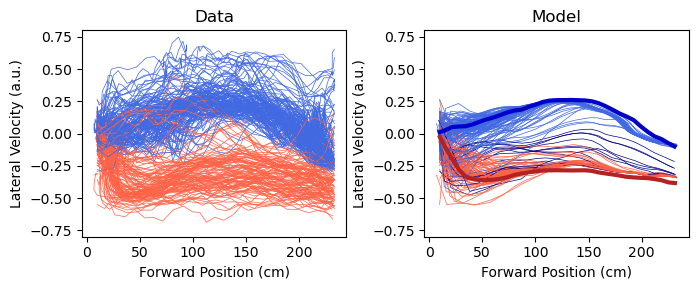

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
colors=[['darkblue','royalblue'],['darkred','tomato']]
#plot individual trials
for idx, trial_index in enumerate(cor_trial_idxes):
    ax[0].plot(cp.asnumpy(behavior[3, frame_trial == trial_index]), 
             -1*cp.asnumpy(behavior[1, frame_trial == trial_index]),
             c=colors[binary_labels[1][trial_index]][1],lw=0.3)
    ax[1].plot(cp.asnumpy(beh_model[3, np.array(frame_trial_eval) == trial_index]), 
             -1*cp.asnumpy(beh_model[1, np.array(frame_trial_eval) == trial_index]),
             c=colors[binary_labels[1][trial_index]][int(correct_m[idx])],lw=0.3)
#plot the simulation from trial averaged initial conditions
ax[1].plot(cp.asnumpy(behavior[3, frame_trial == train_trial_idxes[0]]), 
        -1*cp.asnumpy(behavior[1, frame_trial == train_trial_idxes[0]]),
        c='firebrick',lw=3)
ax[1].plot(cp.asnumpy(behavior[3, frame_trial == train_trial_idxes[1]]), 
        -1*cp.asnumpy(behavior[1, frame_trial == train_trial_idxes[1]]),
        c='mediumblue',lw=3)
ax[0].set_title('Data')
ax[0].set_xlabel('Forward Position (cm)')
ax[0].set_ylabel('Lateral Velocity (a.u.)')
ax[0].set_ylim(-0.8,0.8)
ax[1].set_title('Model')
ax[1].set_xlabel('Forward Position (cm)')
ax[1].set_ylabel('Lateral Velocity (a.u.)')
ax[1].set_ylim(-0.8,0.8)
plt.tight_layout()